# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI job Impact Dataset](https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_job_impact.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


## last Five row

In [4]:
df.tail()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31
1999,E2000,23,Other,Master,Marketing,SEO Specialist,0,High,High,Yes,33830,34809,Modified,37,Yes,9,24.40


## Shape of our dataset

In [5]:
df.shape

(2000, 17)

## List out all columns

In [6]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Employee_ID               object
Age                        int64
Gender                    object
Education_Level           object
Industry                  object
Job_Role                  object
Years_Experience           int64
AI_Adoption_Level         object
Automation_Risk           object
Upskilling_Required       object
Salary_Before_AI           int64
Salary_After_AI            int64
Job_Status                object
Work_Hours_Per_Week        int64
Remote_Work               object
Job_Satisfaction           int64
Productivity_Change_%    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   AI_Adoption_Level      2000 non-null   object 
 8   Automation_Risk        2000 non-null   object 
 9   Upskilling_Required    2000 non-null   object 
 10  Salary_Before_AI       2000 non-null   int64  
 11  Salary_After_AI        2000 non-null   int64  
 12  Job_Status             2000 non-null   object 
 13  Work_Hours_Per_Week    2000 non-null   int64  
 14  Remote_Work            2000 non-null   object 
 15  Job_

## Check Null Value

In [9]:
df.isnull().sum()

Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
Job_Satisfaction         0
Productivity_Change_%    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

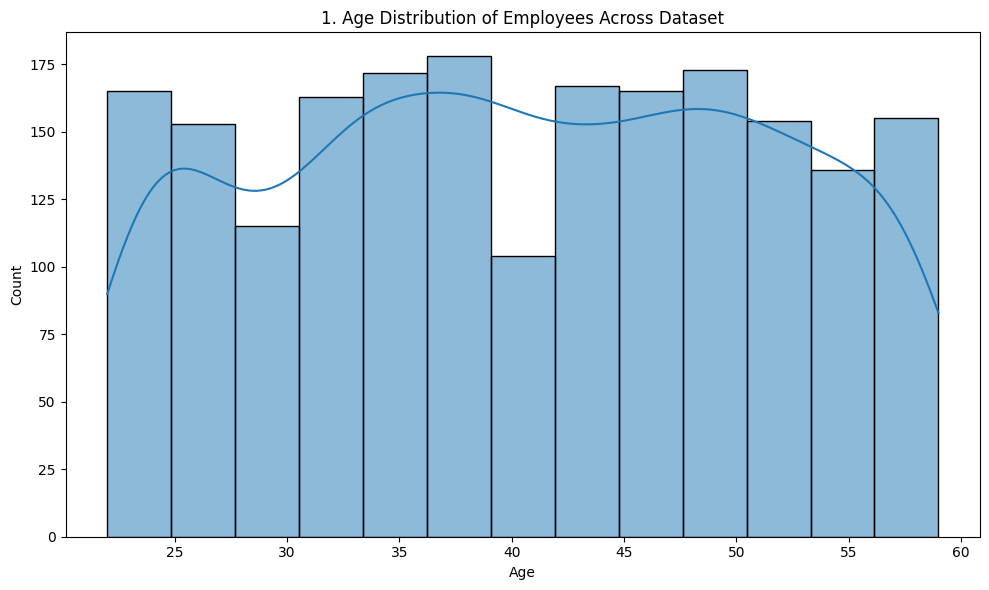

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Employees Across Dataset')
show_fig()
plot_no += 1

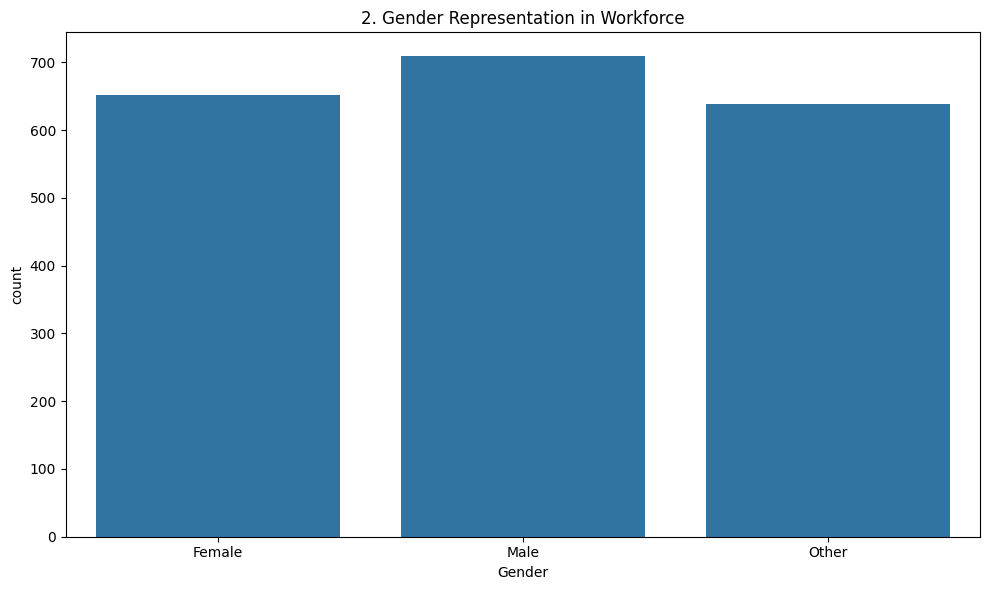

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title(f'{plot_no}. Gender Representation in Workforce')
show_fig()
plot_no += 1

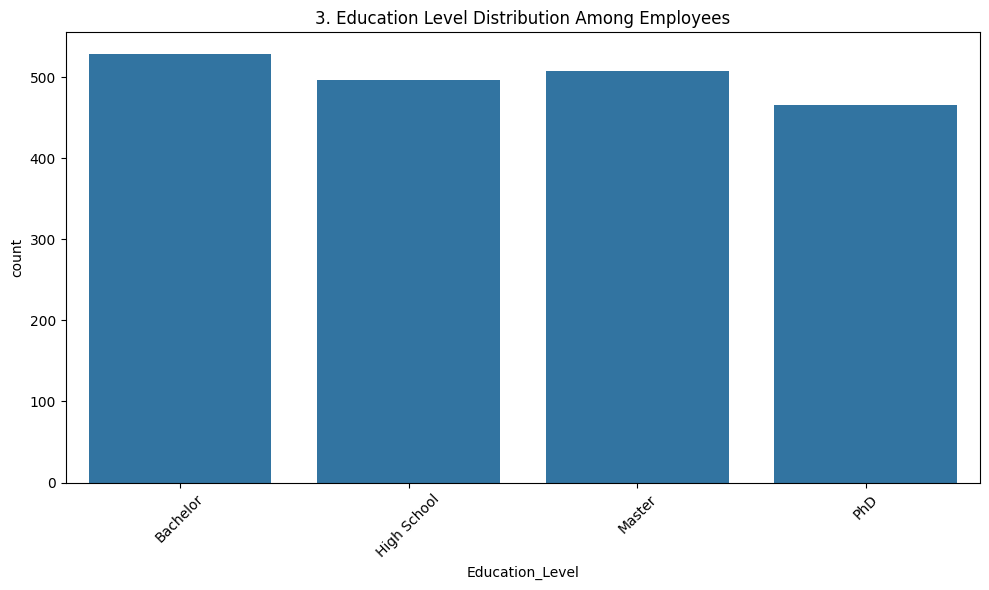

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Education_Level', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Education Level Distribution Among Employees')
show_fig()
plot_no += 1

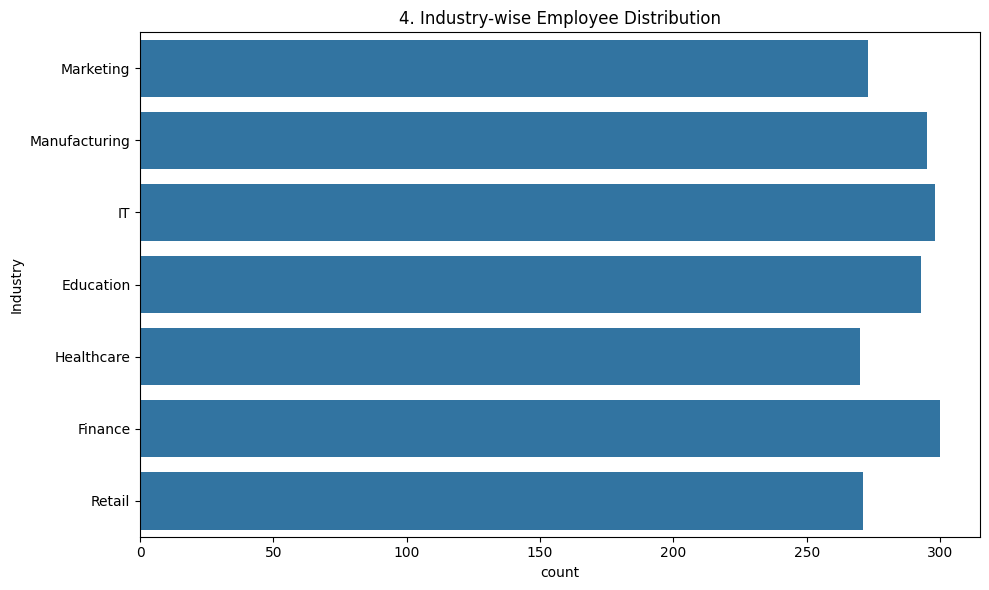

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Industry', data=df)
plt.title(f'{plot_no}. Industry-wise Employee Distribution')
show_fig()
plot_no += 1

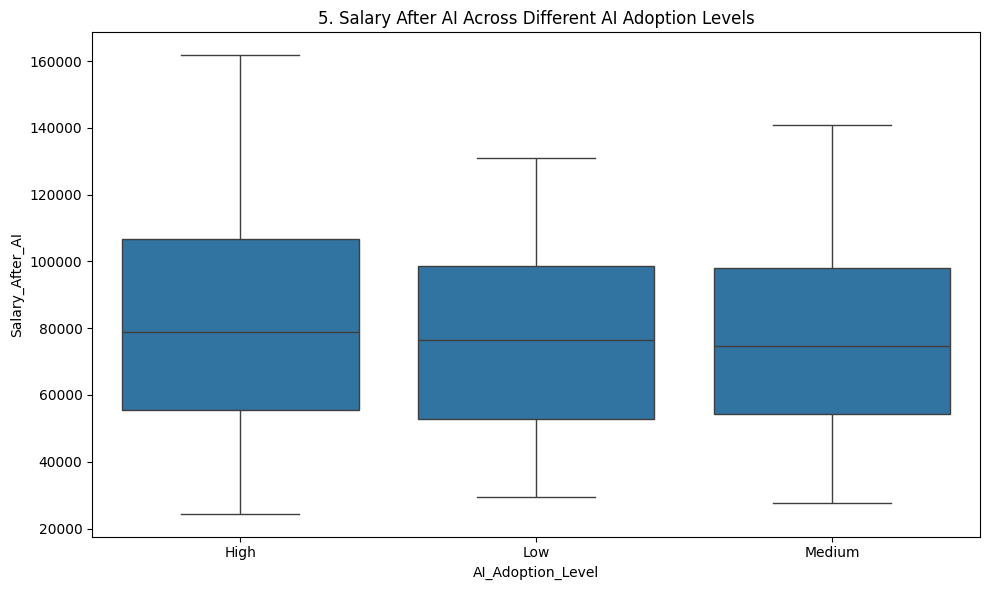

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='AI_Adoption_Level', y='Salary_After_AI', data=df)
plt.title(f'{plot_no}. Salary After AI Across Different AI Adoption Levels')
show_fig()
plot_no += 1

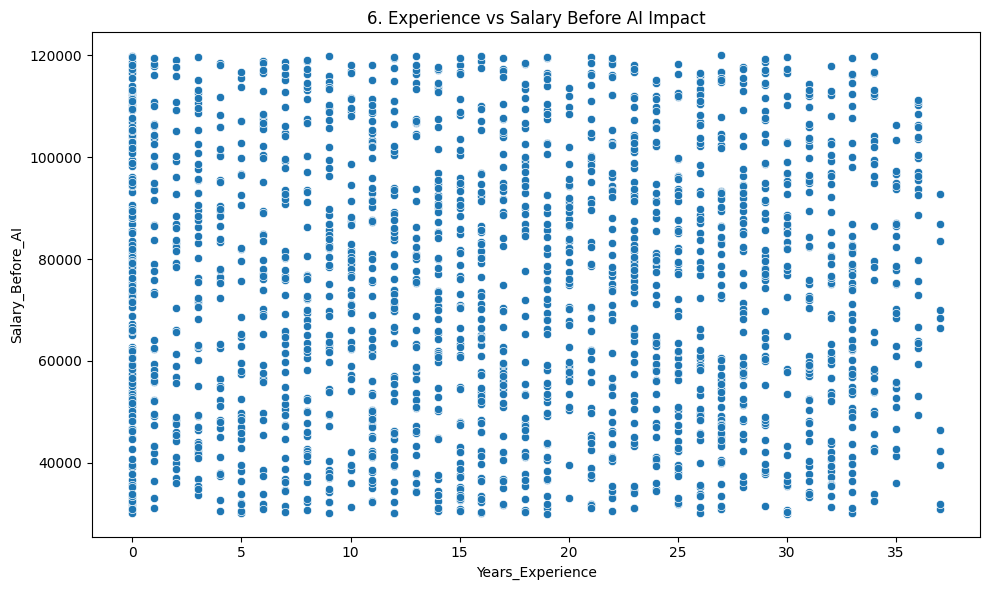

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Years_Experience', y='Salary_Before_AI', data=df)
plt.title(f'{plot_no}. Experience vs Salary Before AI Impact')
show_fig()
plot_no += 1

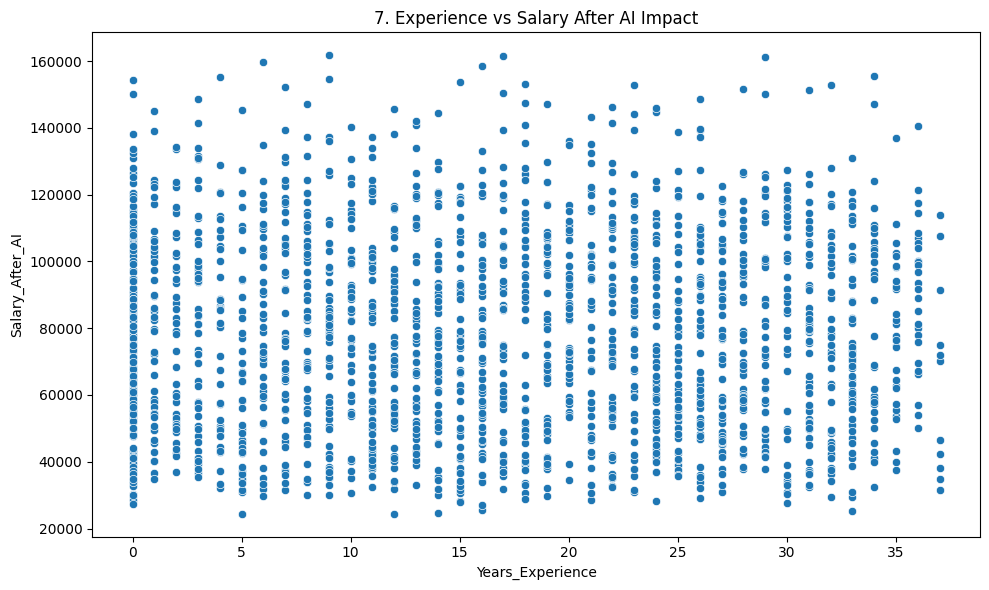

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Years_Experience', y='Salary_After_AI', data=df)
plt.title(f'{plot_no}. Experience vs Salary After AI Impact')
show_fig()
plot_no += 1

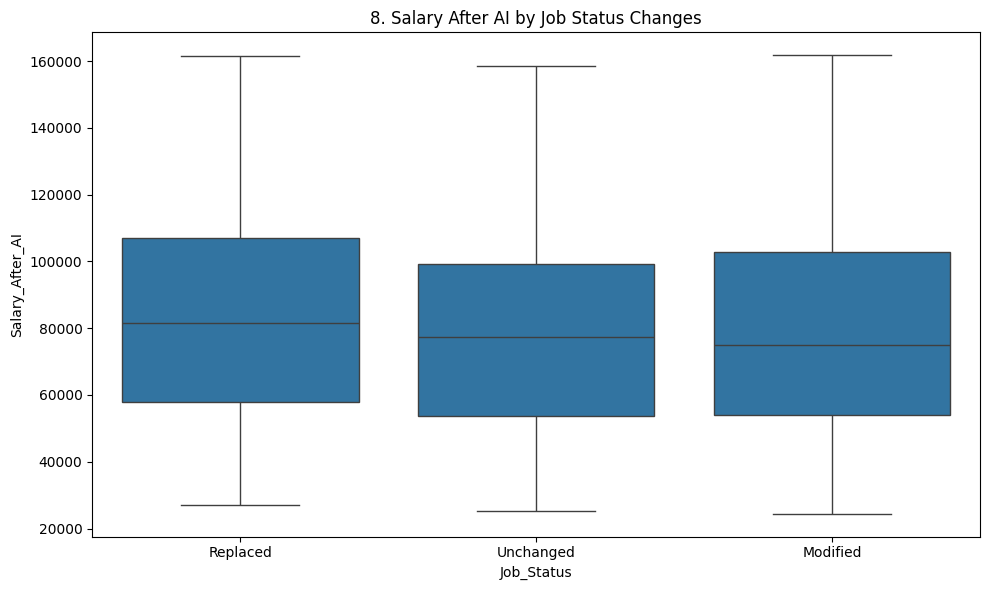

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Job_Status', y='Salary_After_AI', data=df)
plt.title(f'{plot_no}. Salary After AI by Job Status Changes')
show_fig()
plot_no += 1

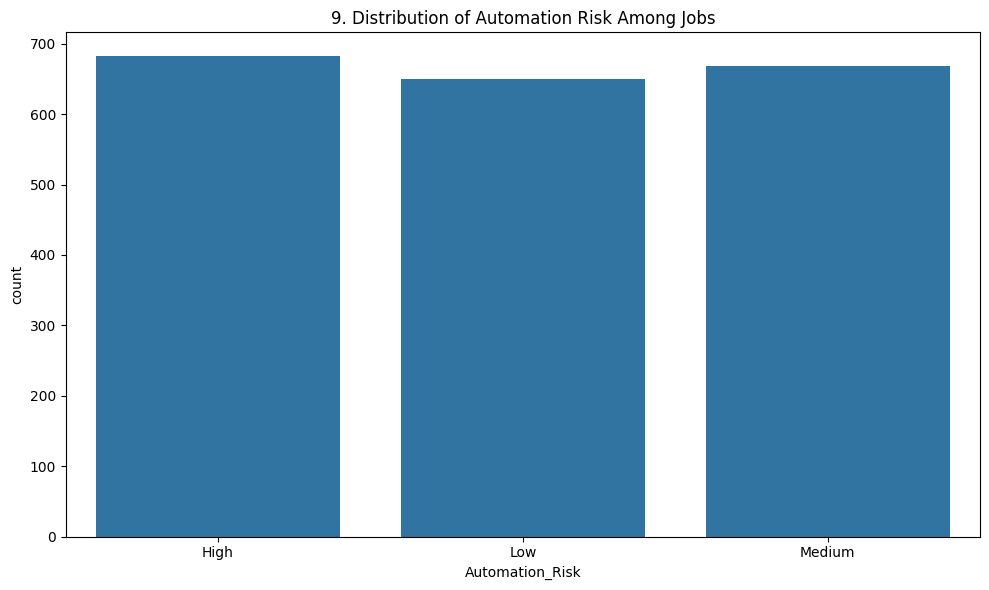

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Automation_Risk', data=df)
plt.title(f'{plot_no}. Distribution of Automation Risk Among Jobs')
show_fig()
plot_no += 1

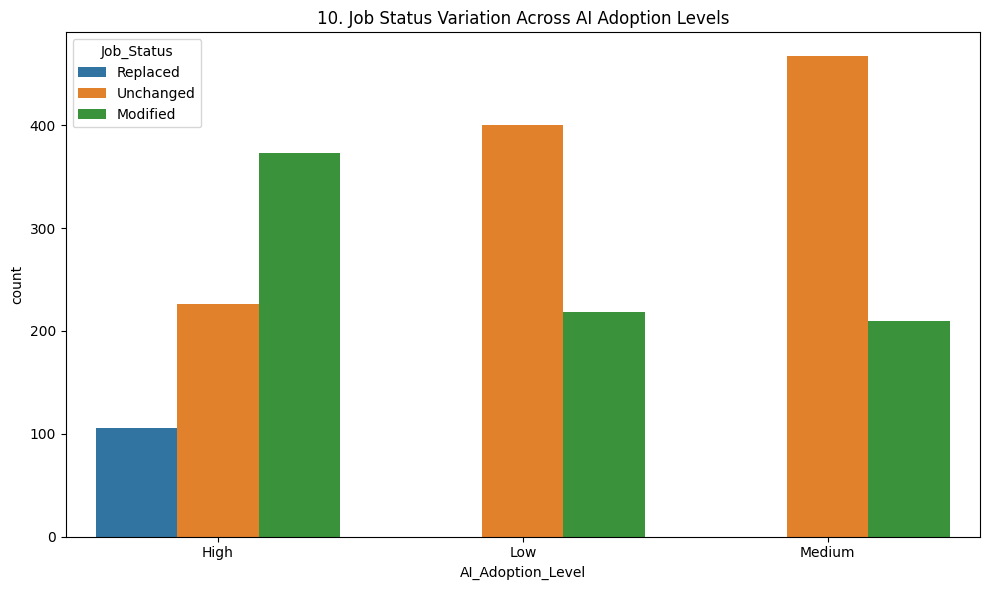

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='AI_Adoption_Level', hue='Job_Status', data=df)
plt.title(f'{plot_no}. Job Status Variation Across AI Adoption Levels')
show_fig()
plot_no += 1

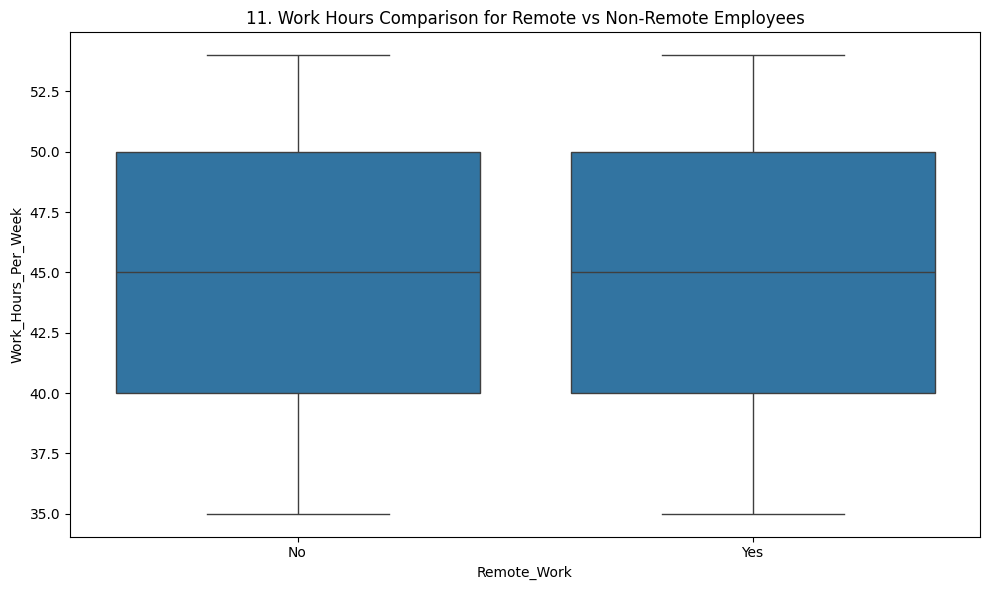

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Remote_Work', y='Work_Hours_Per_Week', data=df)
plt.title(f'{plot_no}. Work Hours Comparison for Remote vs Non-Remote Employees')
show_fig()
plot_no += 1

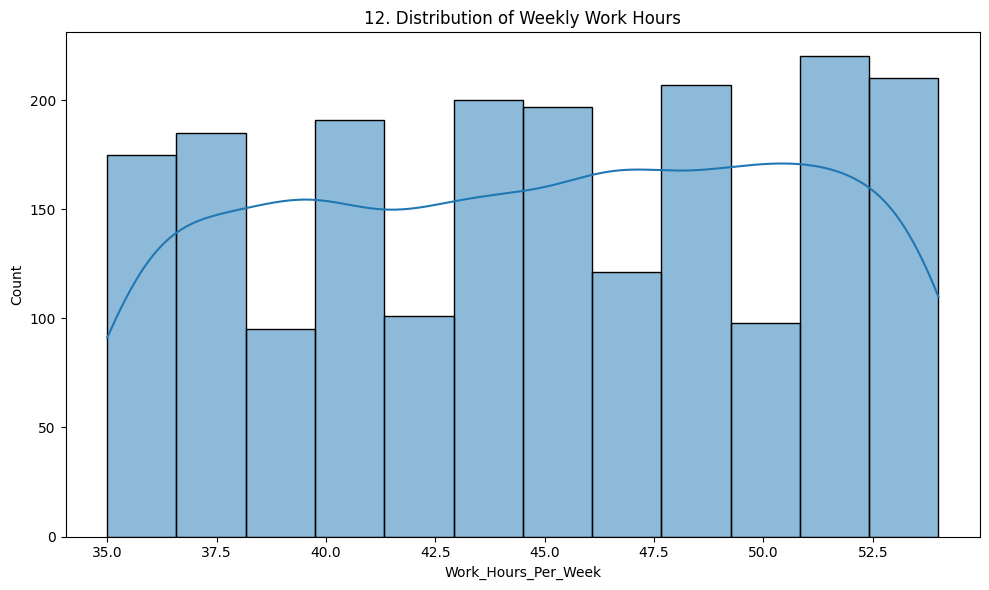

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Work_Hours_Per_Week'], kde=True)
plt.title(f'{plot_no}. Distribution of Weekly Work Hours')
show_fig()
plot_no += 1

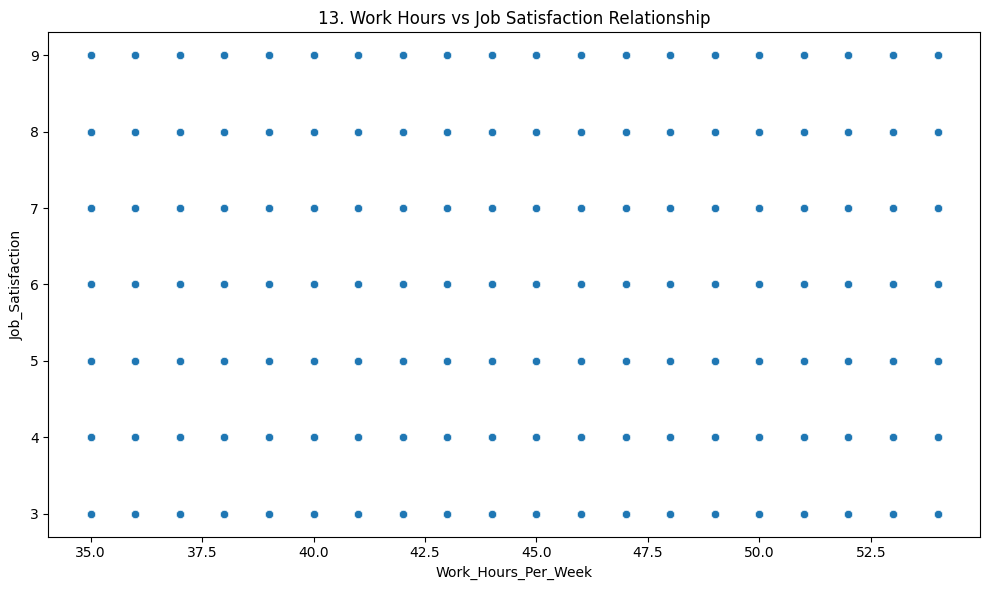

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Work_Hours_Per_Week', y='Job_Satisfaction', data=df)
plt.title(f'{plot_no}. Work Hours vs Job Satisfaction Relationship')
show_fig()
plot_no += 1

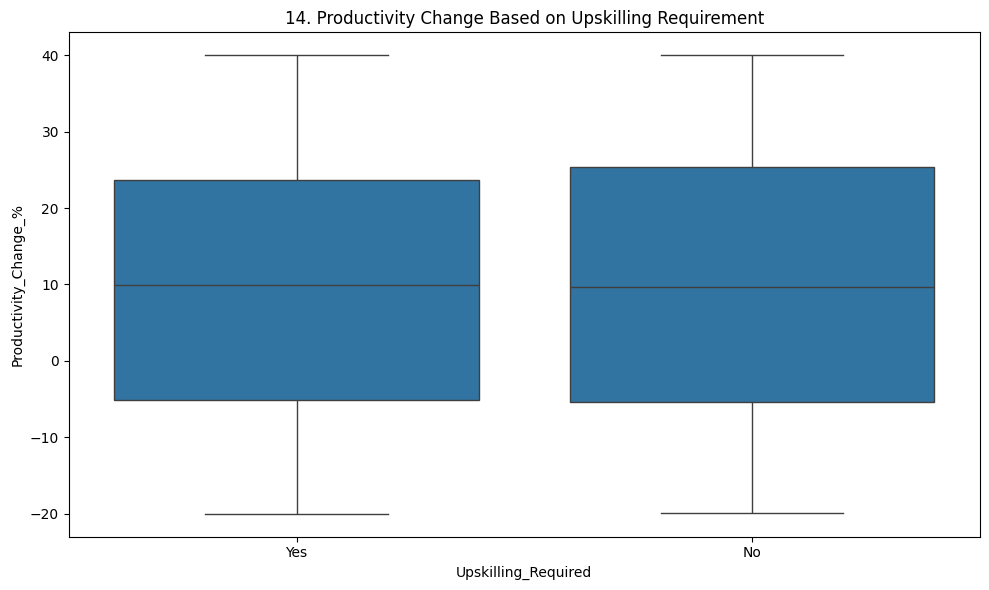

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Upskilling_Required', y='Productivity_Change_%', data=df)
plt.title(f'{plot_no}. Productivity Change Based on Upskilling Requirement')
show_fig()
plot_no += 1

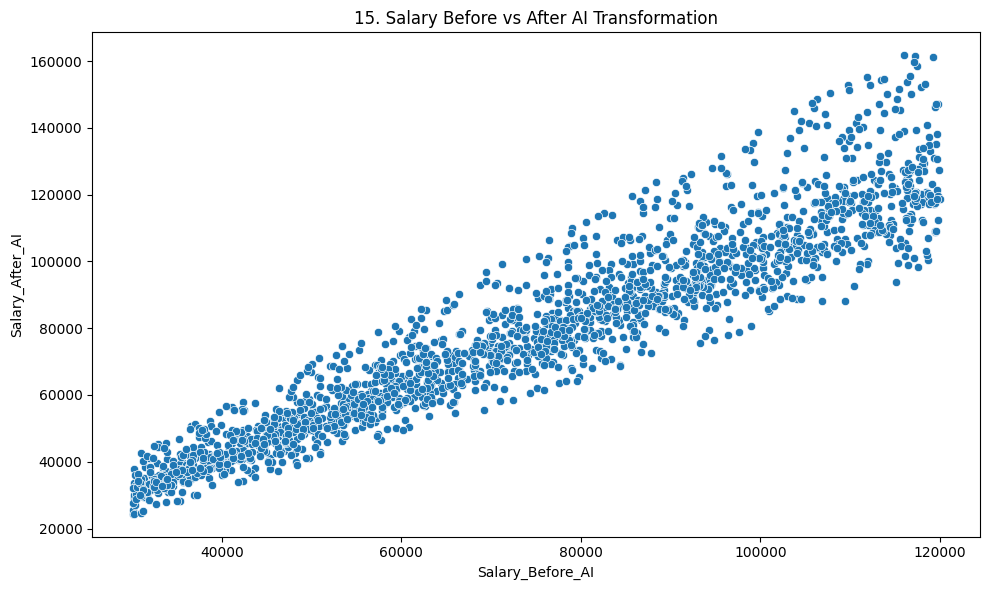

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Salary_Before_AI', y='Salary_After_AI', data=df)
plt.title(f'{plot_no}. Salary Before vs After AI Transformation')
show_fig()
plot_no += 1

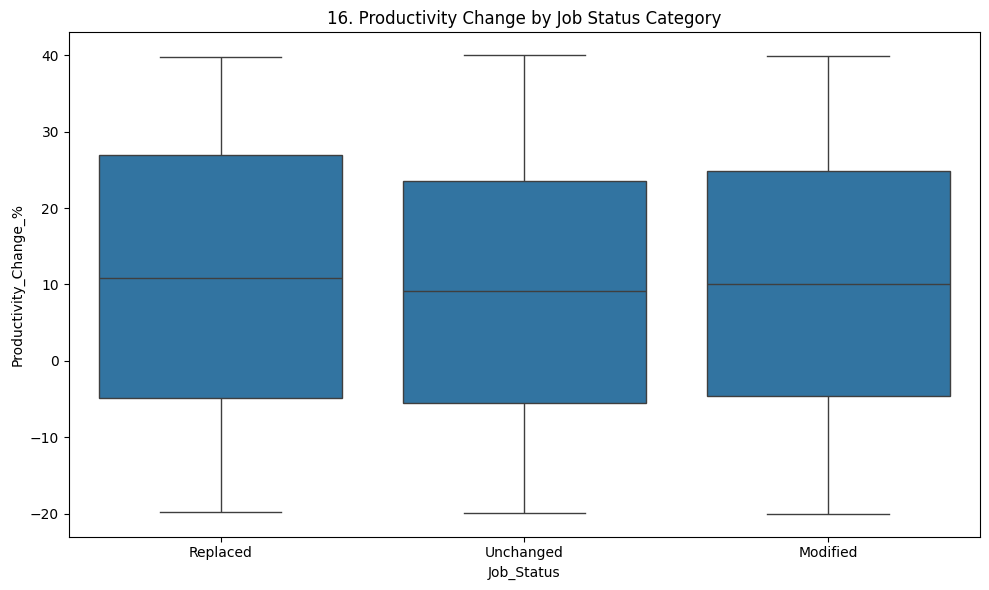

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Job_Status', y='Productivity_Change_%', data=df)
plt.title(f'{plot_no}. Productivity Change by Job Status Category')
show_fig()
plot_no += 1

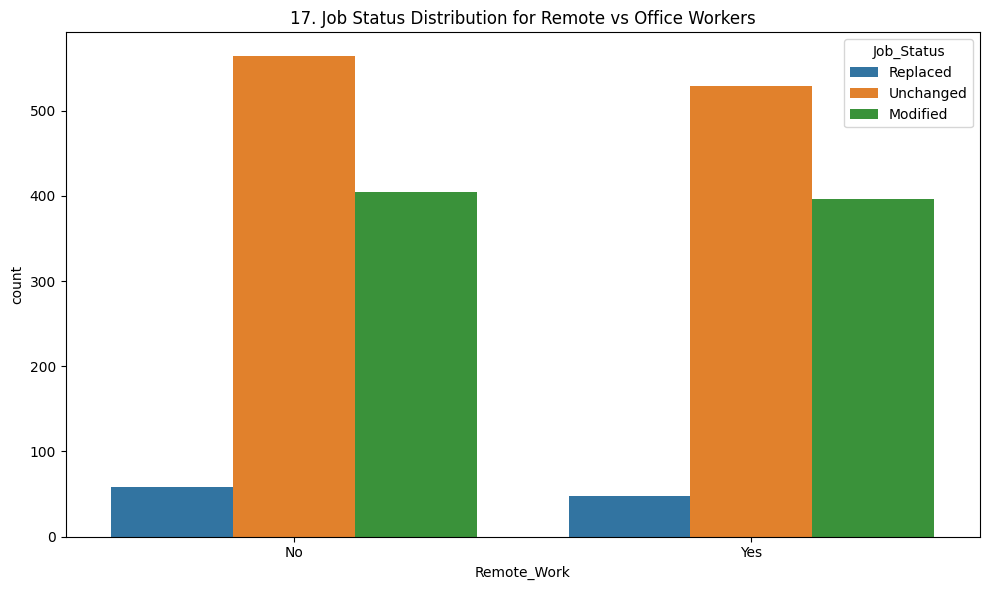

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Remote_Work', hue='Job_Status', data=df)
plt.title(f'{plot_no}. Job Status Distribution for Remote vs Office Workers')
show_fig()
plot_no += 1

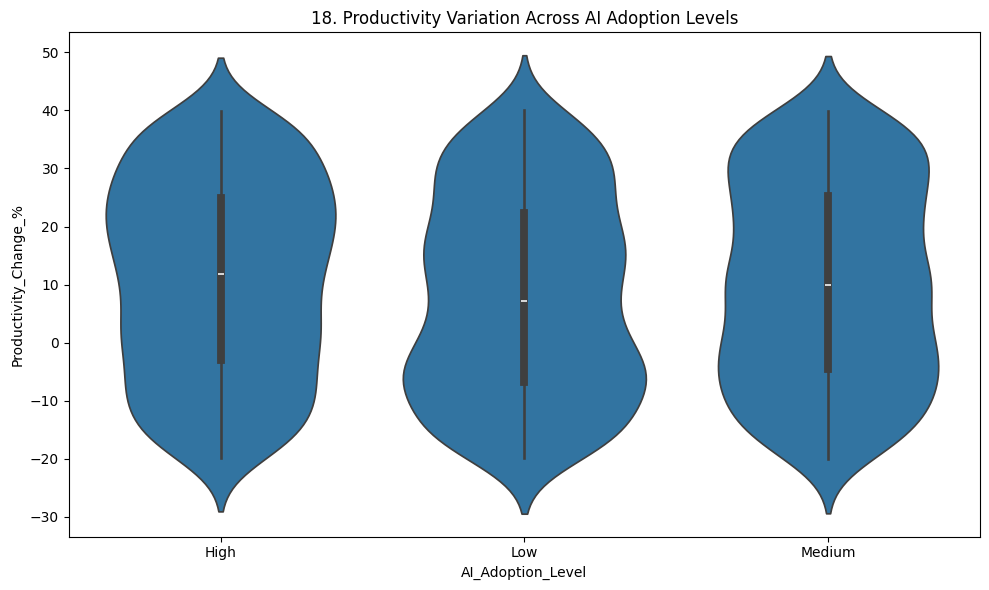

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='AI_Adoption_Level', y='Productivity_Change_%', data=df)
plt.title(f'{plot_no}. Productivity Variation Across AI Adoption Levels')
show_fig()
plot_no += 1

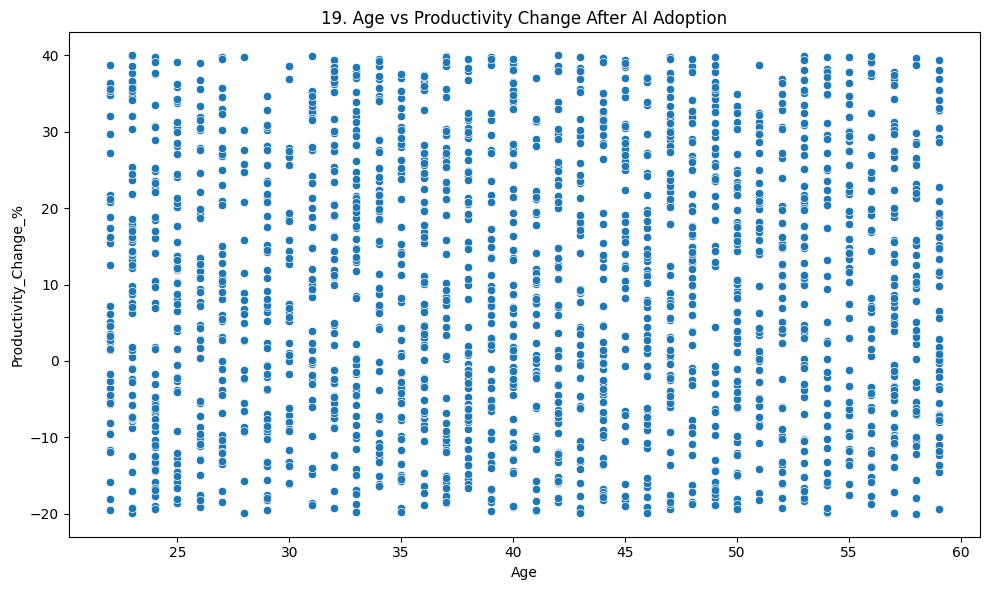

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Productivity_Change_%', data=df)
plt.title(f'{plot_no}. Age vs Productivity Change After AI Adoption')
show_fig()
plot_no += 1

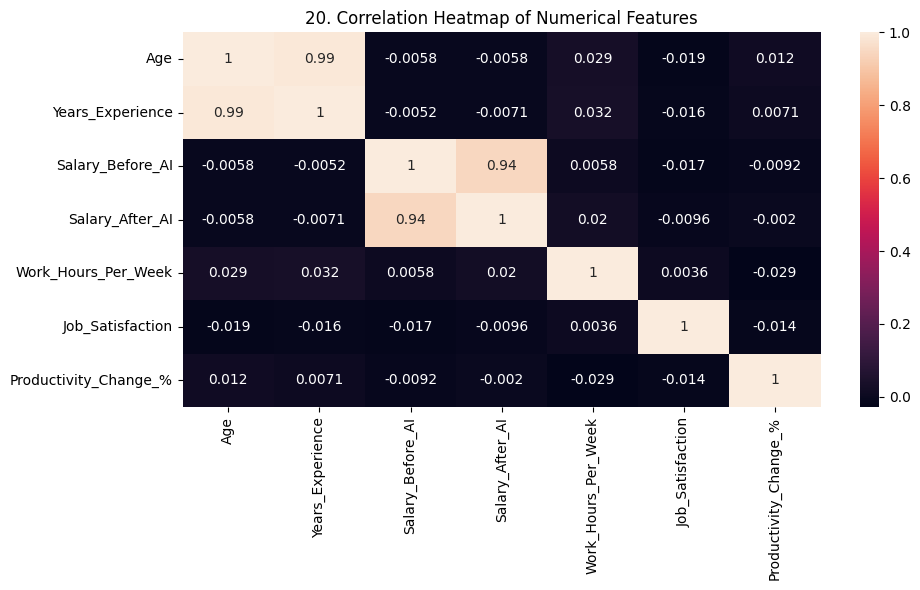

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [33]:
data = df.copy()

## encode categorical columns

In [34]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## define features and target

In [35]:
X = data.drop('Job_Status', axis=1)
y = data['Job_Status']

## split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scaling features

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## predictions

In [39]:
y_pred = model.predict(X_test)

## accuracy score

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8375


## confusion matrix

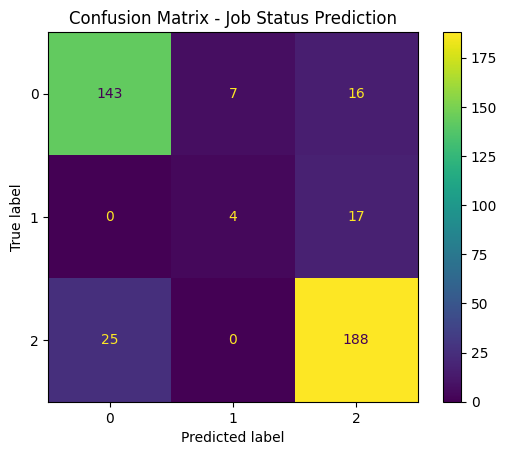

In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Job Status Prediction")
plt.show()